# DDA Agents Evaluation Analysis

This notebook analyzes the evaluation results of different DDA agents and identifies the best performing one.


## 1. Import Libraries and Load Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 11


In [2]:
# Load data
data_dir = Path("data/evaluation")
game_file = data_dir / "dda_evaluation_agents.csv"
interval_file = data_dir / "dda_evaluation_intervals.csv"

# Load game-level data
df_games = pd.read_csv(game_file)
print(f"Loaded {len(df_games)} game records")
print(f"DDA Agents: {df_games['dda_agent_name'].unique()}")
print(f"\nGames per agent:")
print(df_games['dda_agent_name'].value_counts())

# Load interval-level data (optional, for detailed analysis)
if interval_file.exists():
    df_intervals = pd.read_csv(interval_file)
    print(f"\nLoaded {len(df_intervals)} interval records")
else:
    df_intervals = None
    print("\nInterval data not found")

df_games.head()


Loaded 400 game records
DDA Agents: ['RL_best_dda_model_2' 'RL_backup_best_dda_model' 'RL_best_dda_model_1'
 'CNN_best_model']

Games per agent:
dda_agent_name
RL_best_dda_model_2         100
RL_backup_best_dda_model    100
RL_best_dda_model_1         100
CNN_best_model              100
Name: count, dtype: int64

Loaded 50 interval records


,dda_agent_name,game_id,survival_time_steps,total_kills,avg_health_percent,health_std,min_health,time_in_flow_zone_percent,time_in_danger_zone_percent,time_in_safety_zone_percent,near_death_count,near_death_time_percent,action_do_nothing_count,action_slightly_easier_count,action_much_easier_count,action_slightly_harder_count,action_much_harder_count,action_oscillations
0,RL_best_dda_model_2,1,4800,25,91.250000,25.464436,0.0,6.250000,6.250000,87.500000,1,6.250000,0,1,0,0,0,0
1,RL_best_dda_model_2,2,5700,34,69.736842,25.622445,0.0,26.315789,5.263158,68.421053,1,5.263158,0,0,0,0,0,0
2,RL_best_dda_model_2,3,4800,25,90.312500,28.856799,-15.0,6.250000,6.250000,87.500000,1,6.250000,0,0,0,0,0,0
3,RL_best_dda_model_2,4,5100,29,91.764706,24.789774,0.0,5.882353,5.882353,88.235294,1,5.882353,0,0,0,0,0,0
4,RL_best_dda_model_2,5,4800,27,88.750000,27.357586,0.0,6.250000,6.250000,87.500000,1,6.250000,0,1,0,0,0,0


## 2. Data Preprocessing


In [3]:
# Convert survival time from steps to seconds (assuming 60 FPS)
df_games['survival_time_seconds'] = df_games['survival_time_steps'] / 60.0

# Create agent type column (RL vs CNN)
df_games['agent_type'] = df_games['dda_agent_name'].apply(
    lambda x: 'CNN' if x.startswith('CNN_') else 'RL'
)

# Display basic info
print("Data shape:", df_games.shape)
print("\nColumn names:")
print(df_games.columns.tolist())
print("\nData types:")
print(df_games.dtypes)
print("\nMissing values:")
print(df_games.isnull().sum())


Data shape: (400, 20)

Column names:
['dda_agent_name', 'game_id', 'survival_time_steps', 'total_kills', 'avg_health_percent', 'health_std', 'min_health', 'time_in_flow_zone_percent', 'time_in_danger_zone_percent', 'time_in_safety_zone_percent', 'near_death_count', 'near_death_time_percent', 'action_do_nothing_count', 'action_slightly_easier_count', 'action_much_easier_count', 'action_slightly_harder_count', 'action_much_harder_count', 'action_oscillations', 'survival_time_seconds', 'agent_type']

Data types:
dda_agent_name                   object
game_id                           int64
survival_time_steps               int64
total_kills                       int64
avg_health_percent              float64
health_std                      float64
min_health                      float64
time_in_flow_zone_percent       float64
time_in_danger_zone_percent     float64
time_in_safety_zone_percent     float64
near_death_count                  int64
near_death_time_percent         float64
actio

## 3. Descriptive Statistics


In [4]:
# Key metrics for comparison
key_metrics = [
    'survival_time_seconds',
    'total_kills',
    'avg_health_percent',
    'time_in_flow_zone_percent',
    'time_in_danger_zone_percent',
    'time_in_safety_zone_percent',
    'health_std',
    'near_death_count',
    'action_oscillations'
]

# Calculate statistics for each agent
print("="*80)
print("DESCRIPTIVE STATISTICS BY DDA AGENT")
print("="*80)

for agent in df_games['dda_agent_name'].unique():
    agent_data = df_games[df_games['dda_agent_name'] == agent]
    print(f"\n{agent}:")
    print("-" * 80)
    
    for metric in key_metrics:
        if metric in agent_data.columns:
            values = agent_data[metric]
            print(f"  {metric}:")
            print(f"    Mean: {values.mean():.2f}, Std: {values.std():.2f}")
            print(f"    Min: {values.min():.2f}, Max: {values.max():.2f}")


DESCRIPTIVE STATISTICS BY DDA AGENT

RL_best_dda_model_2:
--------------------------------------------------------------------------------
  survival_time_seconds:
    Mean: 89.00, Std: 28.19
    Min: 10.00, Max: 245.00
  total_kills:
    Mean: 30.45, Std: 10.92
    Min: 1.00, Max: 92.00
  avg_health_percent:
    Mean: 87.30, Std: 9.43
    Min: 20.00, Max: 95.24
  time_in_flow_zone_percent:
    Mean: 7.78, Std: 12.11
    Min: 0.00, Max: 66.67
  time_in_danger_zone_percent:
    Mean: 7.48, Std: 5.65
    Min: 2.04, Max: 50.00
  time_in_safety_zone_percent:
    Mean: 84.74, Std: 14.14
    Min: 0.00, Max: 95.45
  health_std:
    Mean: 26.55, Std: 3.53
    Min: 18.98, Max: 43.30
  near_death_count:
    Mean: 1.00, Std: 0.00
    Min: 1.00, Max: 1.00
  action_oscillations:
    Mean: 0.00, Std: 0.00
    Min: 0.00, Max: 0.00

RL_backup_best_dda_model:
--------------------------------------------------------------------------------
  survival_time_seconds:
    Mean: 90.20, Std: 45.83
    Min: 25

## 4. Visualizations - Key Metrics Comparison


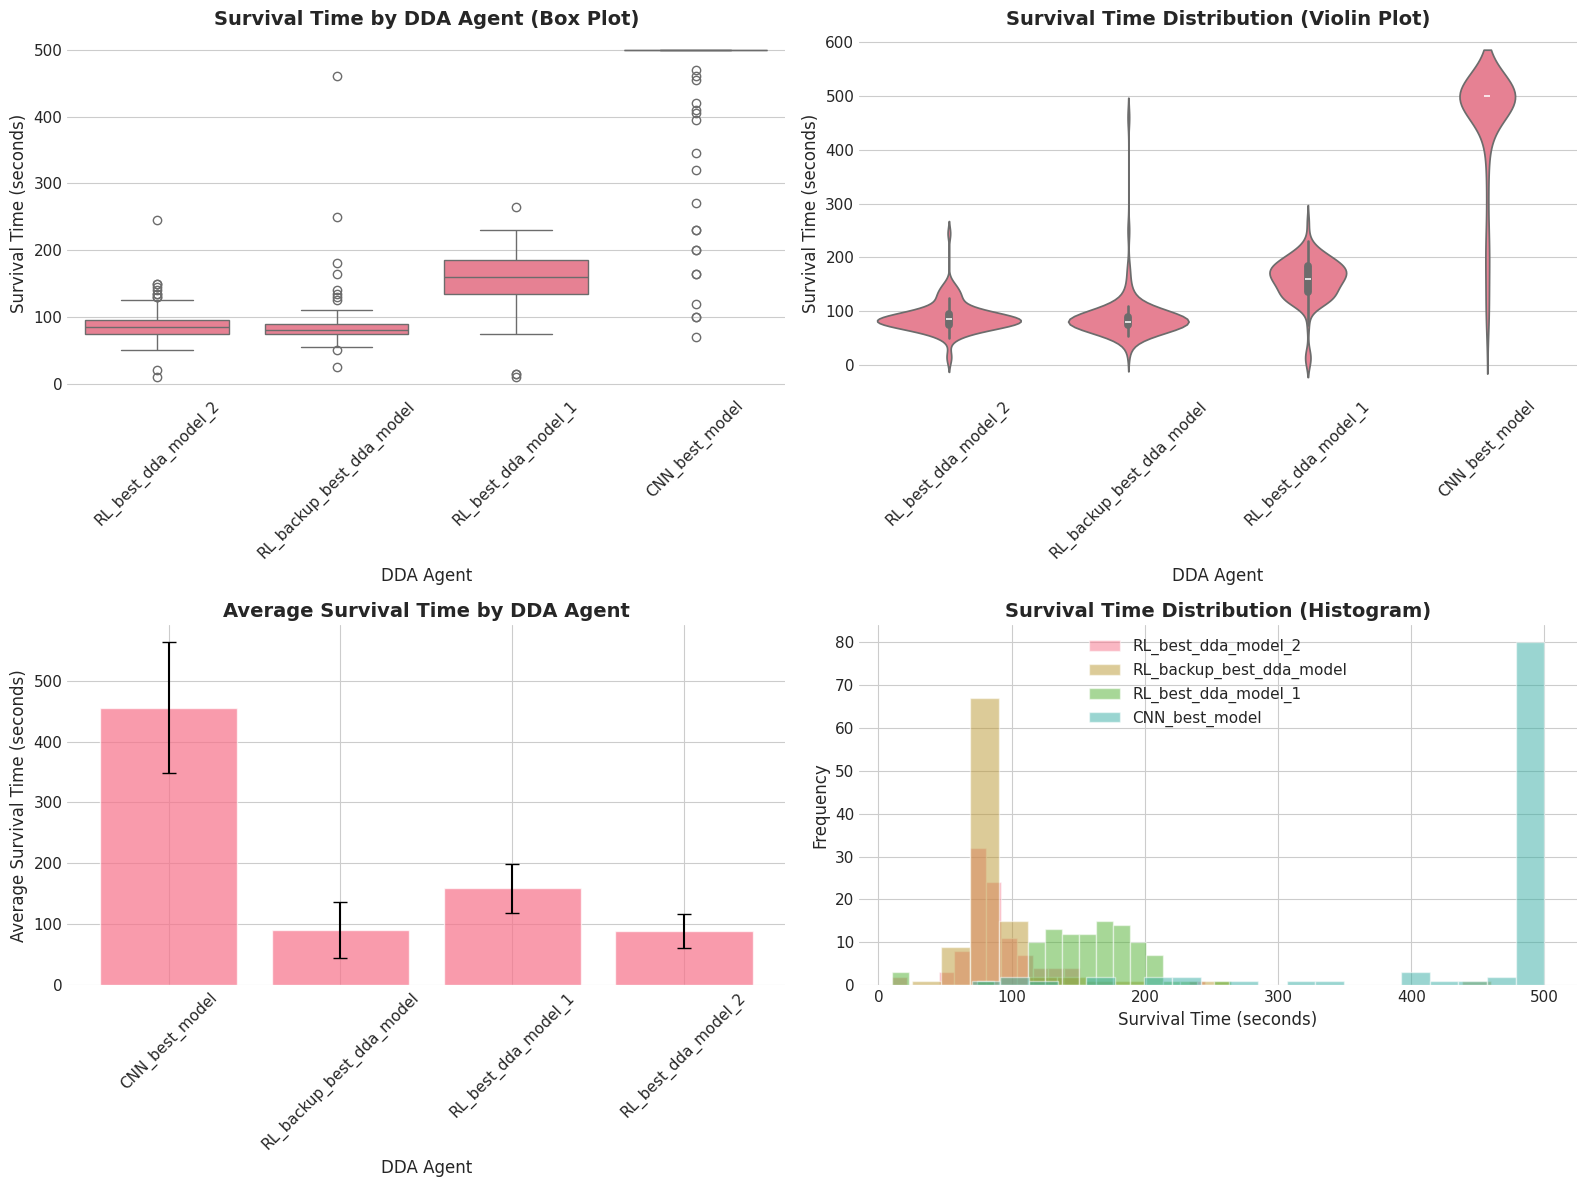

In [5]:
# 4.1 Survival Time Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Box plot
sns.boxplot(data=df_games, x='dda_agent_name', y='survival_time_seconds', ax=axes[0, 0])
axes[0, 0].set_title('Survival Time by DDA Agent (Box Plot)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('DDA Agent', fontsize=12)
axes[0, 0].set_ylabel('Survival Time (seconds)', fontsize=12)
axes[0, 0].tick_params(axis='x', rotation=45)

# Violin plot
sns.violinplot(data=df_games, x='dda_agent_name', y='survival_time_seconds', ax=axes[0, 1])
axes[0, 1].set_title('Survival Time Distribution (Violin Plot)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('DDA Agent', fontsize=12)
axes[0, 1].set_ylabel('Survival Time (seconds)', fontsize=12)
axes[0, 1].tick_params(axis='x', rotation=45)

# Bar plot with error bars
survival_stats = df_games.groupby('dda_agent_name')['survival_time_seconds'].agg(['mean', 'std']).reset_index()
axes[1, 0].bar(survival_stats['dda_agent_name'], survival_stats['mean'], 
               yerr=survival_stats['std'], capsize=5, alpha=0.7)
axes[1, 0].set_title('Average Survival Time by DDA Agent', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('DDA Agent', fontsize=12)
axes[1, 0].set_ylabel('Average Survival Time (seconds)', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=45)

# Histogram overlay
for agent in df_games['dda_agent_name'].unique():
    agent_data = df_games[df_games['dda_agent_name'] == agent]
    axes[1, 1].hist(agent_data['survival_time_seconds'], alpha=0.5, label=agent, bins=20)
axes[1, 1].set_title('Survival Time Distribution (Histogram)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Survival Time (seconds)', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('dda_survival_time_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


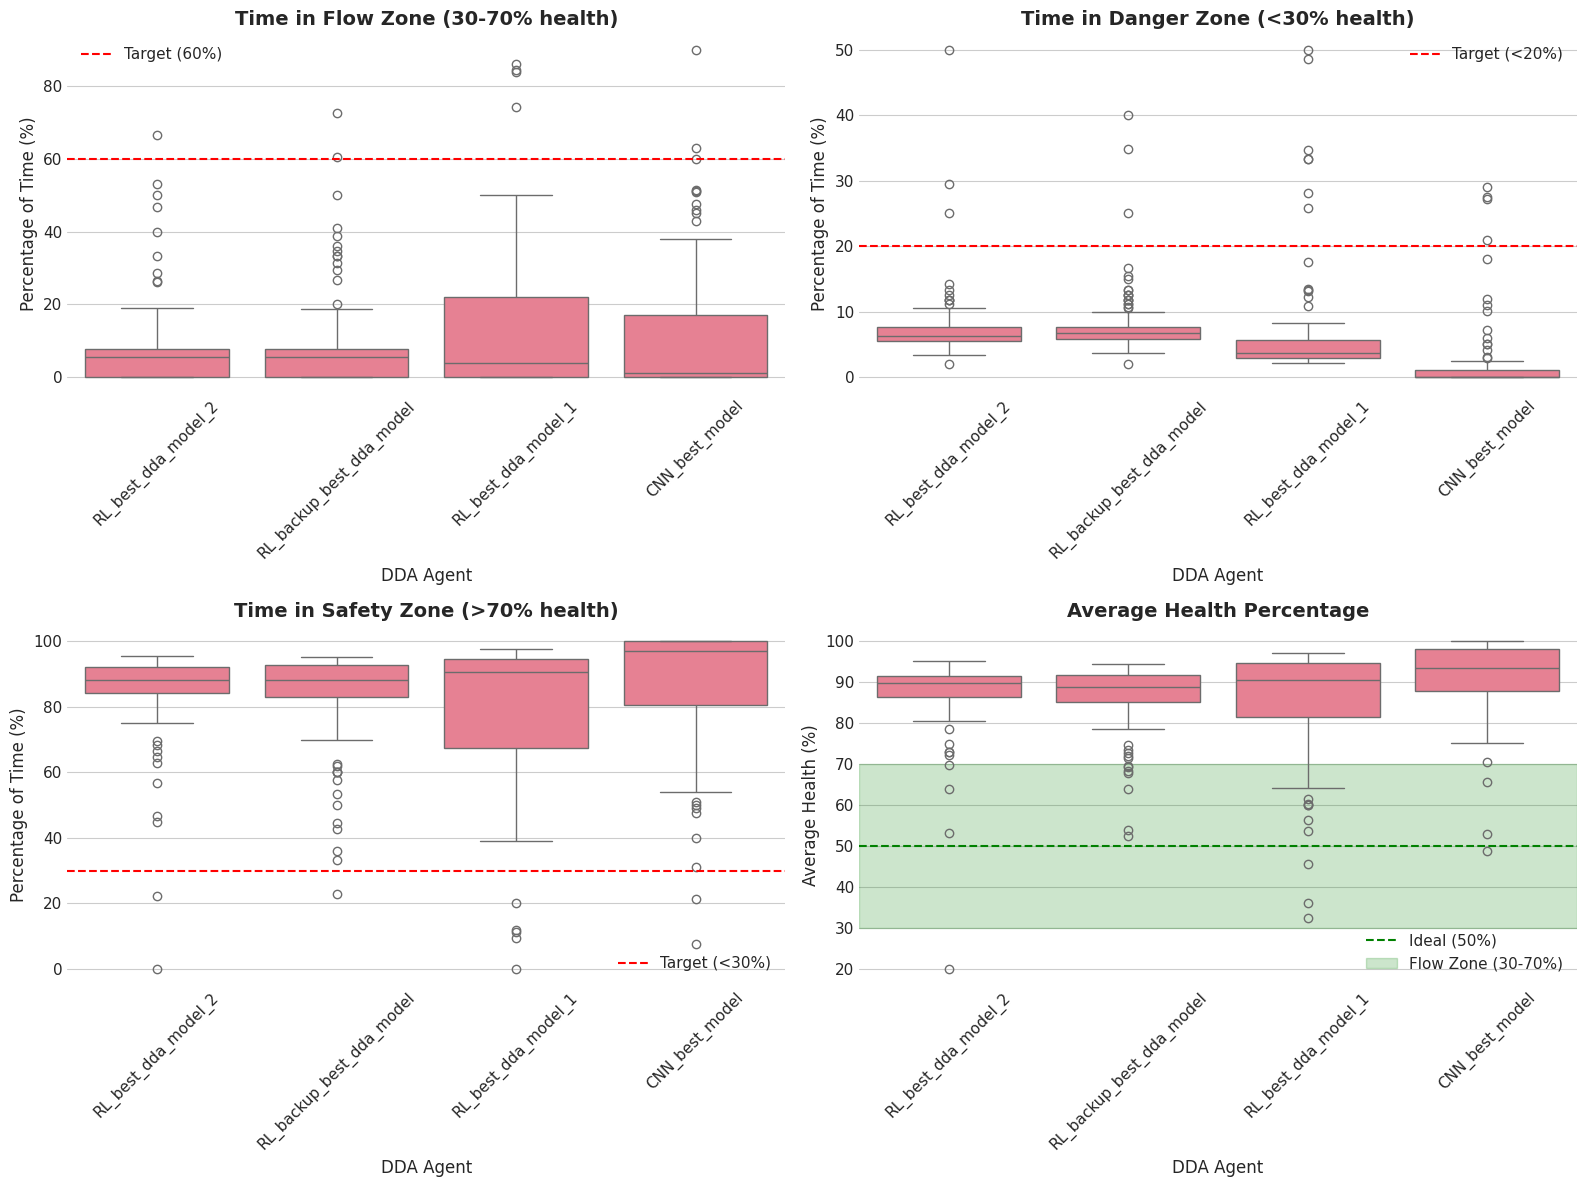

In [6]:
# 4.2 Flow Zone Metrics Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Time in Flow Zone
sns.boxplot(data=df_games, x='dda_agent_name', y='time_in_flow_zone_percent', ax=axes[0, 0])
axes[0, 0].axhline(y=60, color='r', linestyle='--', label='Target (60%)')
axes[0, 0].set_title('Time in Flow Zone (30-70% health)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('DDA Agent', fontsize=12)
axes[0, 0].set_ylabel('Percentage of Time (%)', fontsize=12)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].legend()

# Time in Danger Zone
sns.boxplot(data=df_games, x='dda_agent_name', y='time_in_danger_zone_percent', ax=axes[0, 1])
axes[0, 1].axhline(y=20, color='r', linestyle='--', label='Target (<20%)')
axes[0, 1].set_title('Time in Danger Zone (<30% health)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('DDA Agent', fontsize=12)
axes[0, 1].set_ylabel('Percentage of Time (%)', fontsize=12)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].legend()

# Time in Safety Zone
sns.boxplot(data=df_games, x='dda_agent_name', y='time_in_safety_zone_percent', ax=axes[1, 0])
axes[1, 0].axhline(y=30, color='r', linestyle='--', label='Target (<30%)')
axes[1, 0].set_title('Time in Safety Zone (>70% health)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('DDA Agent', fontsize=12)
axes[1, 0].set_ylabel('Percentage of Time (%)', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend()

# Average Health
sns.boxplot(data=df_games, x='dda_agent_name', y='avg_health_percent', ax=axes[1, 1])
axes[1, 1].axhline(y=50, color='g', linestyle='--', label='Ideal (50%)')
axes[1, 1].axhspan(30, 70, alpha=0.2, color='green', label='Flow Zone (30-70%)')
axes[1, 1].set_title('Average Health Percentage', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('DDA Agent', fontsize=12)
axes[1, 1].set_ylabel('Average Health (%)', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('dda_flow_zone_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


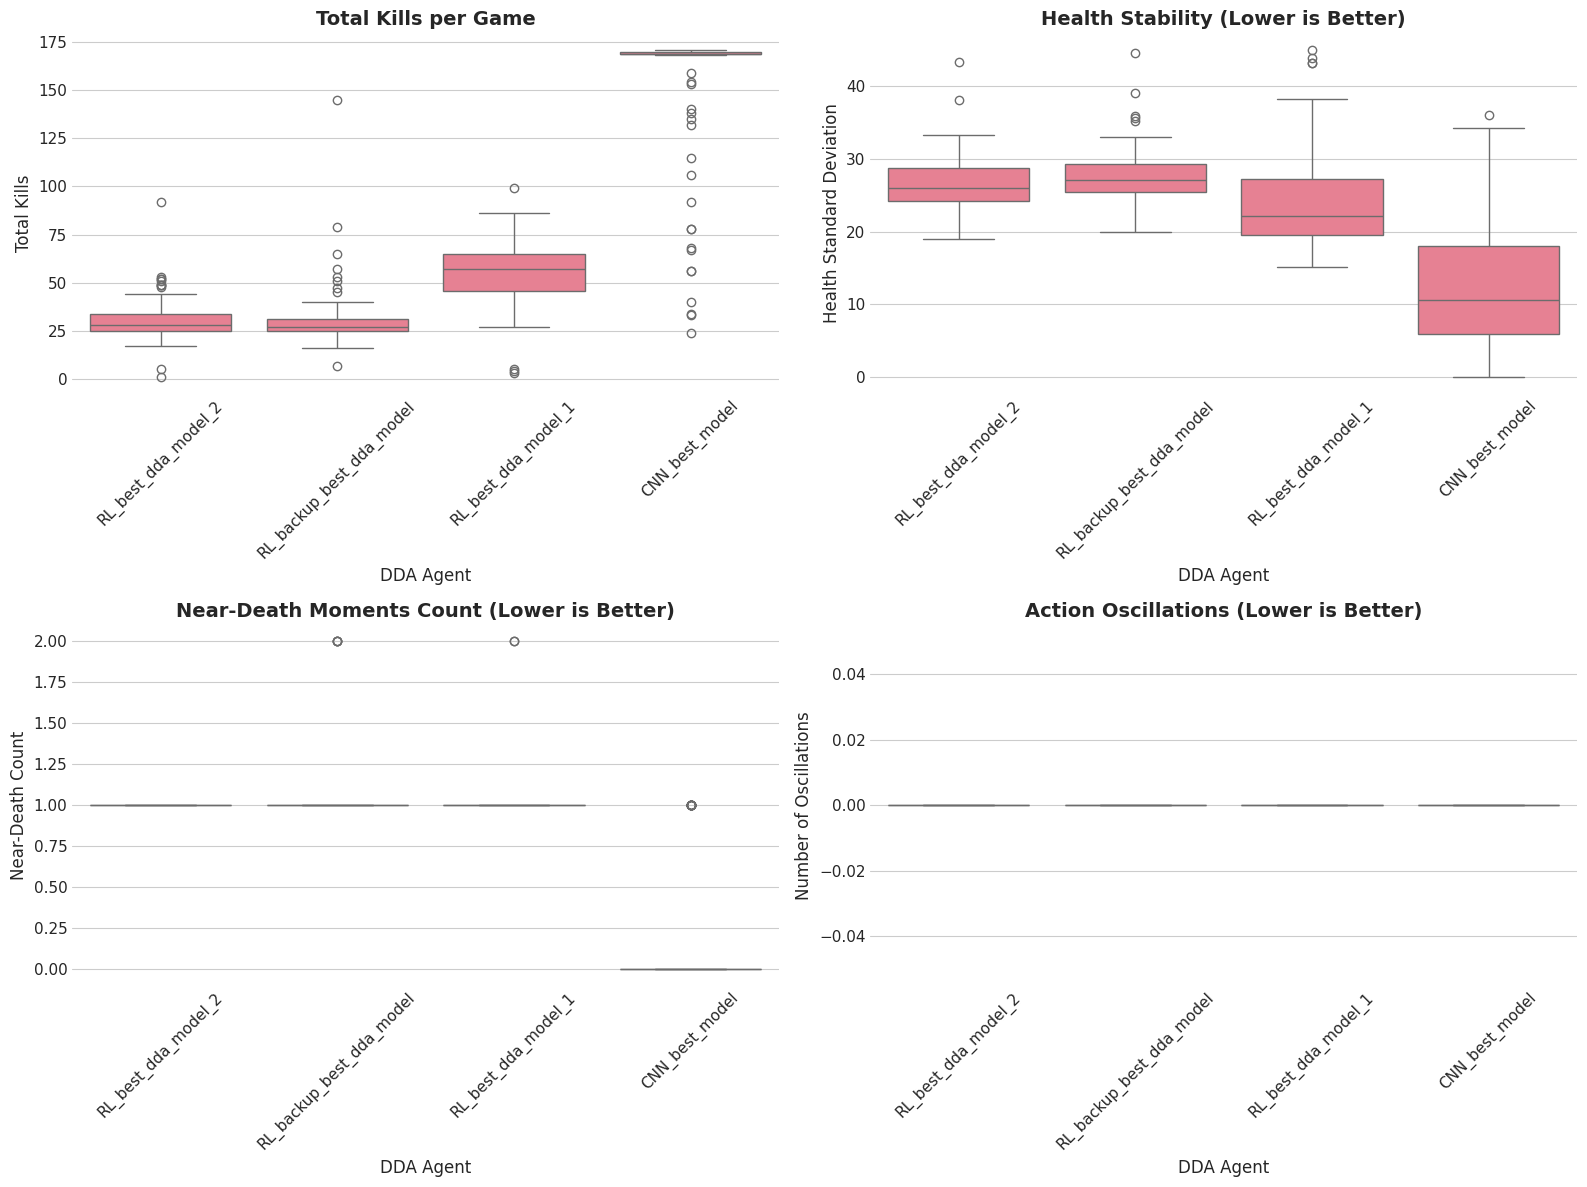

In [7]:
# 4.3 Performance Metrics Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Total Kills
sns.boxplot(data=df_games, x='dda_agent_name', y='total_kills', ax=axes[0, 0])
axes[0, 0].set_title('Total Kills per Game', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('DDA Agent', fontsize=12)
axes[0, 0].set_ylabel('Total Kills', fontsize=12)
axes[0, 0].tick_params(axis='x', rotation=45)

# Health Stability (std)
sns.boxplot(data=df_games, x='dda_agent_name', y='health_std', ax=axes[0, 1])
axes[0, 1].set_title('Health Stability (Lower is Better)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('DDA Agent', fontsize=12)
axes[0, 1].set_ylabel('Health Standard Deviation', fontsize=12)
axes[0, 1].tick_params(axis='x', rotation=45)

# Near Death Count
sns.boxplot(data=df_games, x='dda_agent_name', y='near_death_count', ax=axes[1, 0])
axes[1, 0].set_title('Near-Death Moments Count (Lower is Better)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('DDA Agent', fontsize=12)
axes[1, 0].set_ylabel('Near-Death Count', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=45)

# Action Oscillations
sns.boxplot(data=df_games, x='dda_agent_name', y='action_oscillations', ax=axes[1, 1])
axes[1, 1].set_title('Action Oscillations (Lower is Better)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('DDA Agent', fontsize=12)
axes[1, 1].set_ylabel('Number of Oscillations', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('dda_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


## 5. Ranking and Scoring System


COMPOSITE SCORES BY DDA AGENT
          dda_agent_name     mean      std      min      max
          CNN_best_model 1.672254 0.382186 0.287542 1.985677
     RL_best_dda_model_1 0.628917 0.170506 0.014910 1.037683
RL_backup_best_dda_model 0.360721 0.176421 0.048775 1.647653
     RL_best_dda_model_2 0.356696 0.125113 0.049519 1.069650


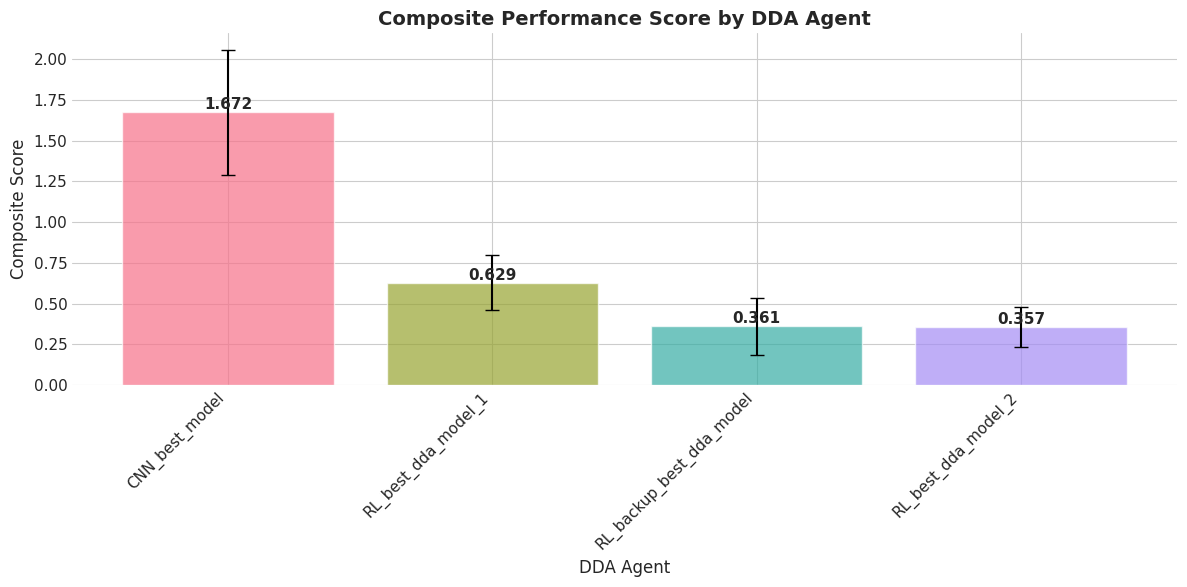

In [8]:
# Calculate composite score for each agent
# Higher is better for: survival_time, kills, flow_zone, avg_health
# Lower is better for: danger_zone, safety_zone, health_std, near_death, oscillations

def calculate_score(row):
    """Calculate composite score for a game."""
    score = 0.0
    
    # Positive contributions (higher is better)
    score += (row['survival_time_seconds'] / 100.0) * 0.25  # Normalize to ~1.0
    score += (row['total_kills'] / 50.0) * 0.15  # Normalize to ~1.0
    score += (row['time_in_flow_zone_percent'] / 100.0) * 0.30  # Most important
    score += (row['avg_health_percent'] / 100.0) * 0.10
    
    # Negative contributions (lower is better)
    score -= (row['time_in_danger_zone_percent'] / 100.0) * 0.10
    score -= (row['time_in_safety_zone_percent'] / 100.0) * 0.05
    score -= (row['health_std'] / 50.0) * 0.03  # Normalize
    score -= (row['near_death_count'] / 10.0) * 0.02  # Normalize
    
    return max(0, score)  # Ensure non-negative

# Calculate scores
df_games['composite_score'] = df_games.apply(calculate_score, axis=1)

# Calculate average score per agent
agent_scores = df_games.groupby('dda_agent_name')['composite_score'].agg([
    'mean', 'std', 'min', 'max'
]).reset_index()
agent_scores = agent_scores.sort_values('mean', ascending=False)

print("="*80)
print("COMPOSITE SCORES BY DDA AGENT")
print("="*80)
print(agent_scores.to_string(index=False))

# Visualize scores
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(agent_scores))
bars = ax.bar(x_pos, agent_scores['mean'], yerr=agent_scores['std'], 
              capsize=5, alpha=0.7, color=sns.color_palette("husl", len(agent_scores)))
ax.set_xlabel('DDA Agent', fontsize=12)
ax.set_ylabel('Composite Score', fontsize=12)
ax.set_title('Composite Performance Score by DDA Agent', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(agent_scores['dda_agent_name'], rotation=45, ha='right')

# Add value labels on bars
for i, (bar, mean_val) in enumerate(zip(bars, agent_scores['mean'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{mean_val:.3f}',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('dda_composite_scores.png', dpi=300, bbox_inches='tight')
plt.show()


In [9]:
# Rank agents by multiple criteria
print("="*80)
print("AGENT RANKING BY KEY METRICS")
print("="*80)

ranking_metrics = {
    'Survival Time': ('survival_time_seconds', 'descending'),
    'Total Kills': ('total_kills', 'descending'),
    'Flow Zone Time': ('time_in_flow_zone_percent', 'descending'),
    'Health Stability': ('health_std', 'ascending'),  # Lower is better
    'Danger Zone Time': ('time_in_danger_zone_percent', 'ascending'),  # Lower is better
    'Composite Score': ('composite_score', 'descending')
}

rankings = {}
for metric_name, (col, order) in ranking_metrics.items():
    if order == 'descending':
        ranked = df_games.groupby('dda_agent_name')[col].mean().sort_values(ascending=False)
    else:
        ranked = df_games.groupby('dda_agent_name')[col].mean().sort_values(ascending=True)
    
    rankings[metric_name] = ranked.index.tolist()
    
    print(f"\n{metric_name}:")
    for i, agent in enumerate(ranked.index, 1):
        value = ranked[agent]
        print(f"  {i}. {agent}: {value:.2f}")

# Calculate overall ranking (sum of ranks)
overall_ranks = {}
for agent in df_games['dda_agent_name'].unique():
    total_rank = 0
    for metric_name, ranked_agents in rankings.items():
        rank = ranked_agents.index(agent) + 1  # 1-based ranking
        total_rank += rank
    overall_ranks[agent] = total_rank

# Sort by total rank (lower is better)
final_ranking = sorted(overall_ranks.items(), key=lambda x: x[1])

print("\n" + "="*80)
print("OVERALL RANKING (Sum of Ranks - Lower is Better)")
print("="*80)
for i, (agent, total_rank) in enumerate(final_ranking, 1):
    print(f"{i}. {agent}: Total Rank = {total_rank}")

best_agent = final_ranking[0][0]
print(f"\n🏆 BEST DDA AGENT: {best_agent}")
print("="*80)


AGENT RANKING BY KEY METRICS

Survival Time:
  1. CNN_best_model: 455.30
  2. RL_best_dda_model_1: 158.75
  3. RL_backup_best_dda_model: 90.20
  4. RL_best_dda_model_2: 89.00

Total Kills:
  1. CNN_best_model: 154.42
  2. RL_best_dda_model_1: 56.17
  3. RL_backup_best_dda_model: 30.62
  4. RL_best_dda_model_2: 30.45

Flow Zone Time:
  1. RL_best_dda_model_1: 13.67
  2. CNN_best_model: 10.92
  3. RL_backup_best_dda_model: 8.53
  4. RL_best_dda_model_2: 7.78

Health Stability:
  1. CNN_best_model: 12.36
  2. RL_best_dda_model_1: 23.92
  3. RL_best_dda_model_2: 26.55
  4. RL_backup_best_dda_model: 27.63

Danger Zone Time:
  1. CNN_best_model: 2.08
  2. RL_best_dda_model_1: 6.75
  3. RL_best_dda_model_2: 7.48
  4. RL_backup_best_dda_model: 8.06

Composite Score:
  1. CNN_best_model: 1.67
  2. RL_best_dda_model_1: 0.63
  3. RL_backup_best_dda_model: 0.36
  4. RL_best_dda_model_2: 0.36

OVERALL RANKING (Sum of Ranks - Lower is Better)
1. CNN_best_model: Total Rank = 7
2. RL_best_dda_model_1:

In [10]:
# Detailed summary for the best agent
best_agent_data = df_games[df_games['dda_agent_name'] == best_agent]

print(f"\n{'='*80}")
print(f"DETAILED SUMMARY FOR BEST AGENT: {best_agent}")
print(f"{'='*80}")

summary_metrics = [
    ('Survival Time (seconds)', 'survival_time_seconds'),
    ('Total Kills', 'total_kills'),
    ('Average Health (%)', 'avg_health_percent'),
    ('Time in Flow Zone (%)', 'time_in_flow_zone_percent'),
    ('Time in Danger Zone (%)', 'time_in_danger_zone_percent'),
    ('Time in Safety Zone (%)', 'time_in_safety_zone_percent'),
    ('Health Std', 'health_std'),
    ('Near-Death Count', 'near_death_count'),
    ('Action Oscillations', 'action_oscillations'),
    ('Composite Score', 'composite_score')
]

for metric_name, col in summary_metrics:
    values = best_agent_data[col]
    print(f"\n{metric_name}:")
    print(f"  Mean: {values.mean():.2f}")
    print(f"  Std: {values.std():.2f}")
    print(f"  Min: {values.min():.2f}")
    print(f"  Max: {values.max():.2f}")



DETAILED SUMMARY FOR BEST AGENT: CNN_best_model

Survival Time (seconds):
  Mean: 455.30
  Std: 107.69
  Min: 70.00
  Max: 500.00

Total Kills:
  Mean: 154.42
  Std: 36.74
  Min: 24.00
  Max: 171.00

Average Health (%):
  Mean: 91.39
  Std: 9.38
  Min: 48.79
  Max: 100.00

Time in Flow Zone (%):
  Mean: 10.92
  Std: 17.88
  Min: 0.00
  Max: 90.00

Time in Danger Zone (%):
  Mean: 2.08
  Std: 5.73
  Min: 0.00
  Max: 29.00

Time in Safety Zone (%):
  Mean: 87.01
  Std: 19.31
  Min: 7.50
  Max: 100.00

Health Std:
  Mean: 12.36
  Std: 8.87
  Min: 0.00
  Max: 36.10

Near-Death Count:
  Mean: 0.20
  Std: 0.40
  Min: 0.00
  Max: 1.00

Action Oscillations:
  Mean: 0.00
  Std: 0.00
  Min: 0.00
  Max: 0.00

Composite Score:
  Mean: 1.67
  Std: 0.38
  Min: 0.29
  Max: 1.99


## 7. Action Distribution Analysis


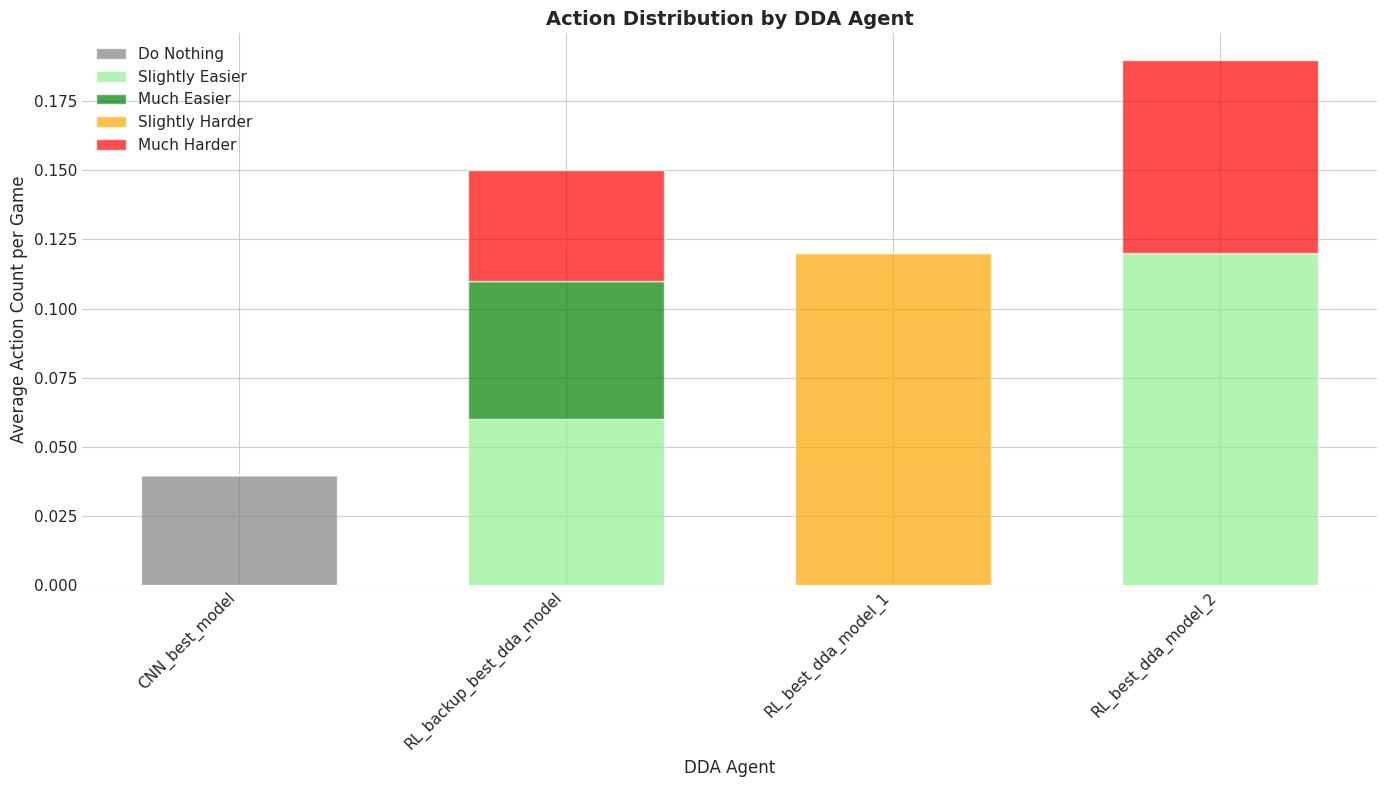

AVERAGE ACTION DISTRIBUTION PER GAME
          dda_agent_name  action_do_nothing_count  action_slightly_easier_count  action_much_easier_count  action_slightly_harder_count  action_much_harder_count
          CNN_best_model                     0.04                          0.00                      0.00                          0.00                      0.00
RL_backup_best_dda_model                     0.00                          0.06                      0.05                          0.00                      0.04
     RL_best_dda_model_1                     0.00                          0.00                      0.00                          0.12                      0.00
     RL_best_dda_model_2                     0.00                          0.12                      0.00                          0.00                      0.07


In [11]:
# Analyze action distribution for each agent
action_cols = [
    'action_do_nothing_count',
    'action_slightly_easier_count',
    'action_much_easier_count',
    'action_slightly_harder_count',
    'action_much_harder_count'
]

# Calculate average action counts per agent
action_stats = df_games.groupby('dda_agent_name')[action_cols].mean().reset_index()

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(14, 8))

agents = action_stats['dda_agent_name']
x_pos = np.arange(len(agents))
width = 0.6

action_names = [
    'Do Nothing',
    'Slightly Easier',
    'Much Easier',
    'Slightly Harder',
    'Much Harder'
]

colors = ['gray', 'lightgreen', 'green', 'orange', 'red']
bottom = np.zeros(len(agents))

for i, (col, name, color) in enumerate(zip(action_cols, action_names, colors)):
    values = action_stats[col].values
    ax.bar(x_pos, values, width, label=name, bottom=bottom, color=color, alpha=0.7)
    bottom += values

ax.set_xlabel('DDA Agent', fontsize=12)
ax.set_ylabel('Average Action Count per Game', fontsize=12)
ax.set_title('Action Distribution by DDA Agent', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(agents, rotation=45, ha='right')
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('dda_action_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Display table
print("="*80)
print("AVERAGE ACTION DISTRIBUTION PER GAME")
print("="*80)
print(action_stats.to_string(index=False))


## 8. Correlation Analysis


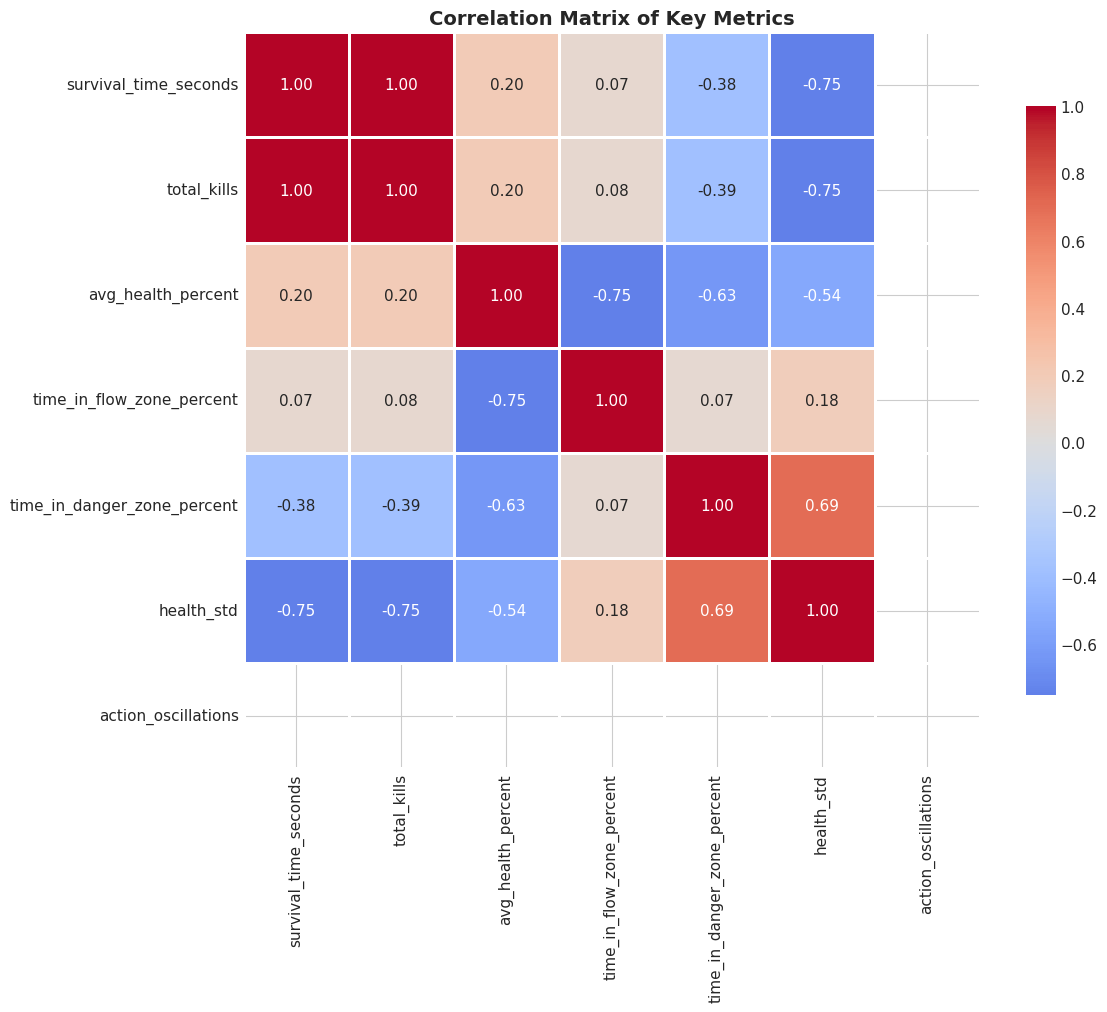

In [12]:
# Calculate correlation matrix for key metrics
correlation_metrics = [
    'survival_time_seconds',
    'total_kills',
    'avg_health_percent',
    'time_in_flow_zone_percent',
    'time_in_danger_zone_percent',
    'health_std',
    'action_oscillations'
]

corr_matrix = df_games[correlation_metrics].corr()

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix of Key Metrics', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('dda_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


## 9. Summary and Recommendations


## 8. Summary and Recommendations


In [13]:
print("="*80)
print("EVALUATION SUMMARY")
print("="*80)

print(f"\nTotal Games Evaluated: {len(df_games)}")
print(f"Number of DDA Agents: {len(df_games['dda_agent_name'].unique())}")
print(f"Games per Agent: {len(df_games) // len(df_games['dda_agent_name'].unique())}")

print(f"\n🏆 Best DDA Agent: {best_agent}")

print(f"\n\nKey Strengths of {best_agent}:")
best_data = df_games[df_games['dda_agent_name'] == best_agent]

# Compare to average
avg_survival = df_games['survival_time_seconds'].mean()
best_survival = best_data['survival_time_seconds'].mean()
if best_survival > avg_survival:
    print(f"  ✓ Survival Time: {best_survival:.1f}s (vs avg {avg_survival:.1f}s) - {((best_survival/avg_survival - 1) * 100):.1f}% better")

avg_flow = df_games['time_in_flow_zone_percent'].mean()
best_flow = best_data['time_in_flow_zone_percent'].mean()
if best_flow > avg_flow:
    print(f"  ✓ Flow Zone Time: {best_flow:.1f}% (vs avg {avg_flow:.1f}%) - {((best_flow/avg_flow - 1) * 100):.1f}% better")

avg_danger = df_games['time_in_danger_zone_percent'].mean()
best_danger = best_data['time_in_danger_zone_percent'].mean()
if best_danger < avg_danger:
    print(f"  ✓ Danger Zone Time: {best_danger:.1f}% (vs avg {avg_danger:.1f}%) - {((1 - best_danger/avg_danger) * 100):.1f}% better")

print(f"\n\nRecommendations:")
print(f"  1. Use {best_agent} for production/testing")
print(f"  2. Further analyze why this agent performs better")
print(f"  3. Consider fine-tuning other agents based on best agent's characteristics")
print(f"  4. Monitor action distribution to ensure balanced difficulty adjustments")

print("\n" + "="*80)


EVALUATION SUMMARY

Total Games Evaluated: 400
Number of DDA Agents: 4
Games per Agent: 100

🏆 Best DDA Agent: CNN_best_model


Key Strengths of CNN_best_model:
  ✓ Survival Time: 455.3s (vs avg 198.3s) - 129.6% better
  ✓ Flow Zone Time: 10.9% (vs avg 10.2%) - 6.8% better
  ✓ Danger Zone Time: 2.1% (vs avg 6.1%) - 65.9% better


Recommendations:
  1. Use CNN_best_model for production/testing
  2. Further analyze why this agent performs better
  3. Consider fine-tuning other agents based on best agent's characteristics
  4. Monitor action distribution to ensure balanced difficulty adjustments



it is really hard to say that this model is better than other
but after seen the satistics the best model that really handle th egame really well
is backup_best_dda_model.pth